# Rossmann Store Sales — Data Loading & EDA

**Goal:** Load and clean the panel dataset (1,115 stores over ~2.5 years), then explore
trends, seasonality, and the effects of promotions and holidays before modeling.

Sections:
1. Load data
2. Merge and basic checks
3. Handle closed-store days
4. Aggregate sales trends over time
5. Seasonality (day-of-week, monthly)
6. Promotion and holiday effects
7. Store-level variation
8. Key takeaways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load Data

Download `train.csv` and `store.csv` from the
[Kaggle competition page](https://www.kaggle.com/c/rossmann-store-sales/data)
and place them in the `data/` folder before running this cell.

In [2]:
train = pd.read_csv('../data/train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('../data/store.csv')

print('train shape:', train.shape)
print('store shape:', store.shape)
train.head()

train shape: (1017209, 9)
store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


## 2. Merge and Basic Checks

In [3]:
df = train.merge(store, on='Store', how='left')
print(df.shape)
df.info()

(1017209, 18)
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567

In [4]:
# Missing values
print(df.isnull().sum().sort_values(ascending=False).head(10))

Promo2SinceWeek              508031
PromoInterval                508031
Promo2SinceYear              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Store                             0
Date                              0
Sales                             0
dtype: int64


In [5]:
# Date range and number of stores
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Number of unique stores:', df['Store'].nunique())

Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Number of unique stores: 1115


## 3. Handle Closed-Store Days

Sales = 0 when a store is closed (`Open = 0`). These rows should generally be excluded from
modeling and from most EDA about sales *levels*, since they're not informative about demand
-- they just reflect the store being shut.

In [6]:
closed_pct = (df['Open'] == 0).mean()
print(f'% of rows where store is closed: {closed_pct:.1%}')

# Keep a copy with closed days for reference, and a clean open-only version for most analysis
df_open = df[df['Open'] == 1].copy()
print('Shape after removing closed days:', df_open.shape)

% of rows where store is closed: 17.0%
Shape after removing closed days: (844392, 18)


## 4. Aggregate Sales Trends Over Time

Start with the big picture: total sales across all stores, over time.

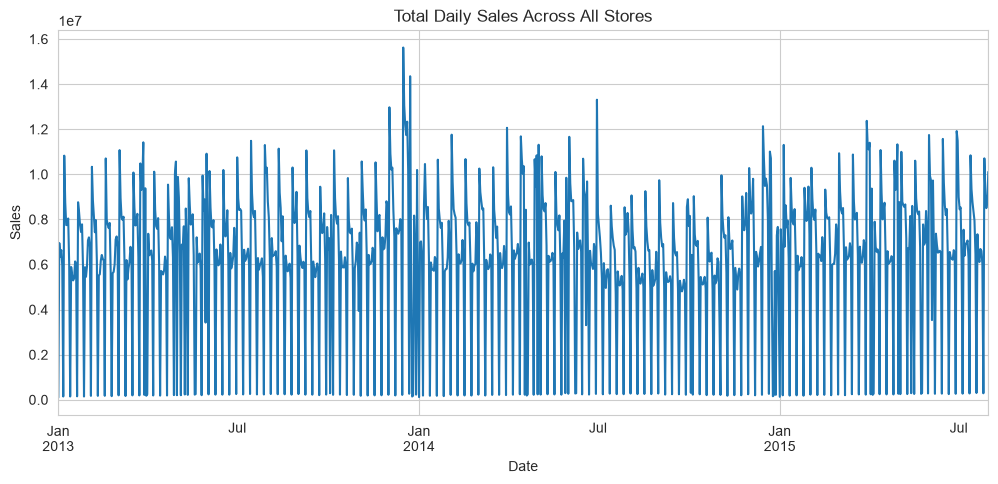

In [7]:
daily_sales = df_open.groupby('Date')['Sales'].sum()

daily_sales.plot()
plt.title('Total Daily Sales Across All Stores')
plt.ylabel('Sales')
plt.show()

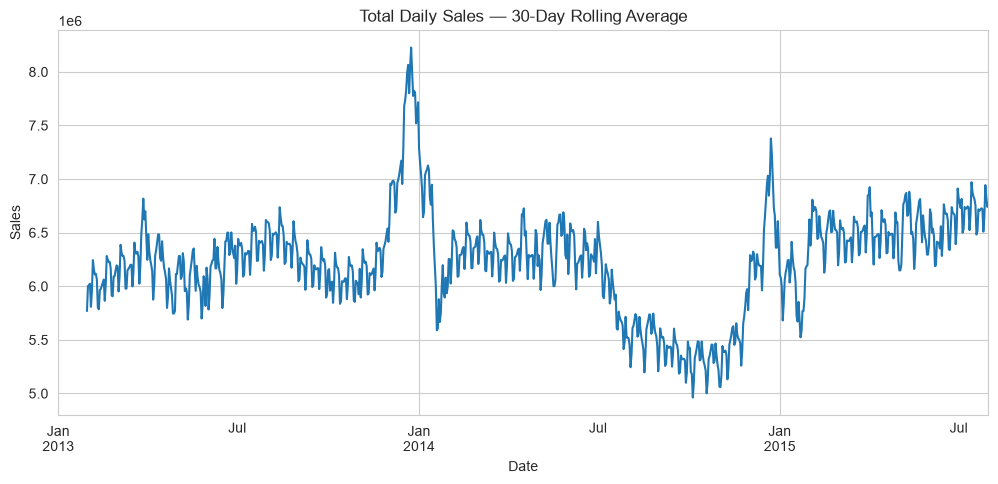

In [8]:
# Smoothed with a 30-day rolling average to see the underlying trend more clearly
daily_sales.rolling(30).mean().plot()
plt.title('Total Daily Sales — 30-Day Rolling Average')
plt.ylabel('Sales')
plt.show()

## 5. Seasonality

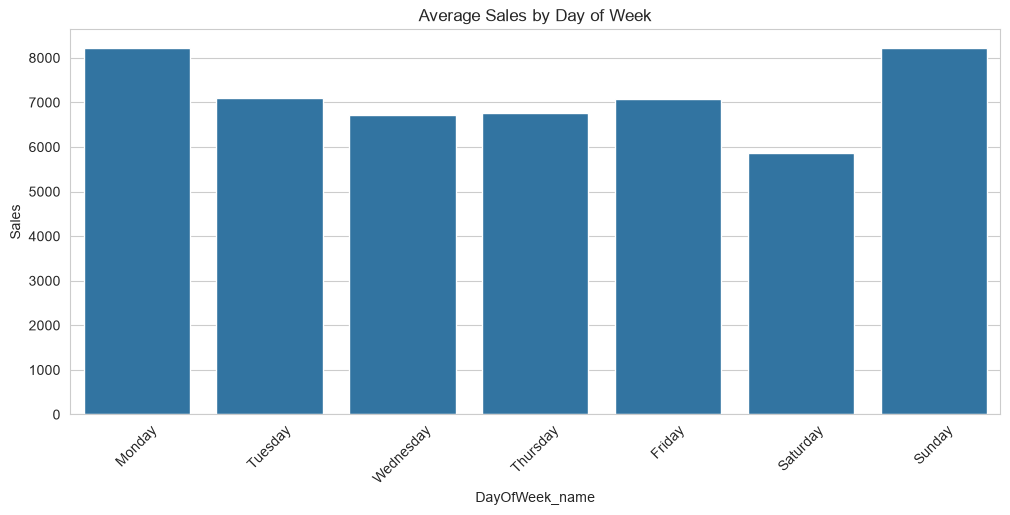

In [9]:
df_open['DayOfWeek_name'] = df_open['Date'].dt.day_name()
df_open['Month'] = df_open['Date'].dt.month

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(
    data=df_open, x='DayOfWeek_name', y='Sales', order=dow_order, errorbar=None
)
plt.title('Average Sales by Day of Week')
plt.xticks(rotation=45)
plt.show()

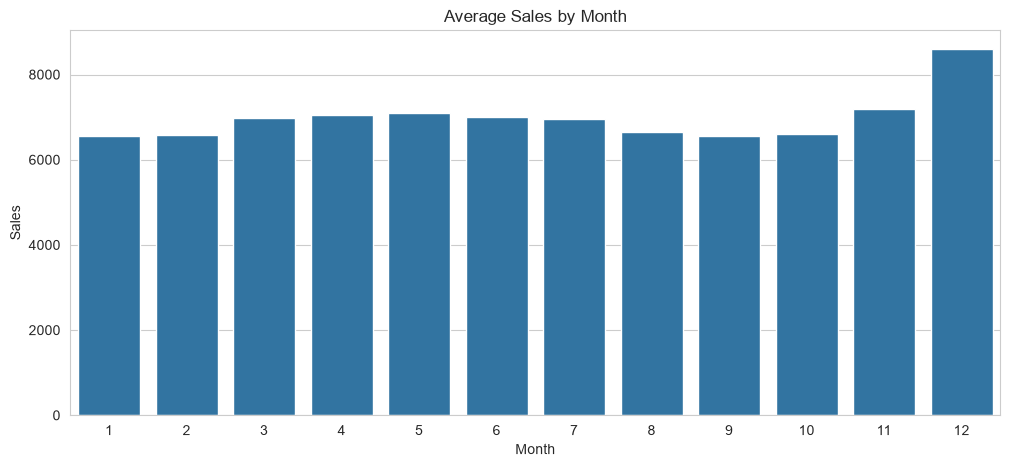

In [10]:
sns.barplot(data=df_open, x='Month', y='Sales', errorbar=None)
plt.title('Average Sales by Month')
plt.show()

## 6. Promotion and Holiday Effects

This is the core of the 'how much lift does a promotion actually generate' question.

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64

Estimated promo lift: 38.8%


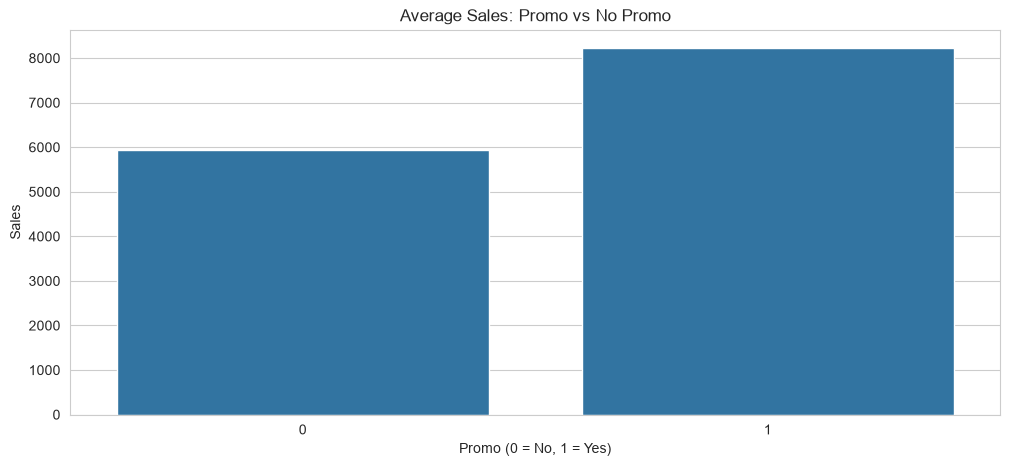

In [11]:
promo_effect = df_open.groupby('Promo')['Sales'].mean()
print(promo_effect)
print(f"\nEstimated promo lift: {(promo_effect[1] / promo_effect[0] - 1):.1%}")

sns.barplot(data=df_open, x='Promo', y='Sales', errorbar=None)
plt.title('Average Sales: Promo vs No Promo')
plt.xlabel('Promo (0 = No, 1 = Yes)')
plt.show()

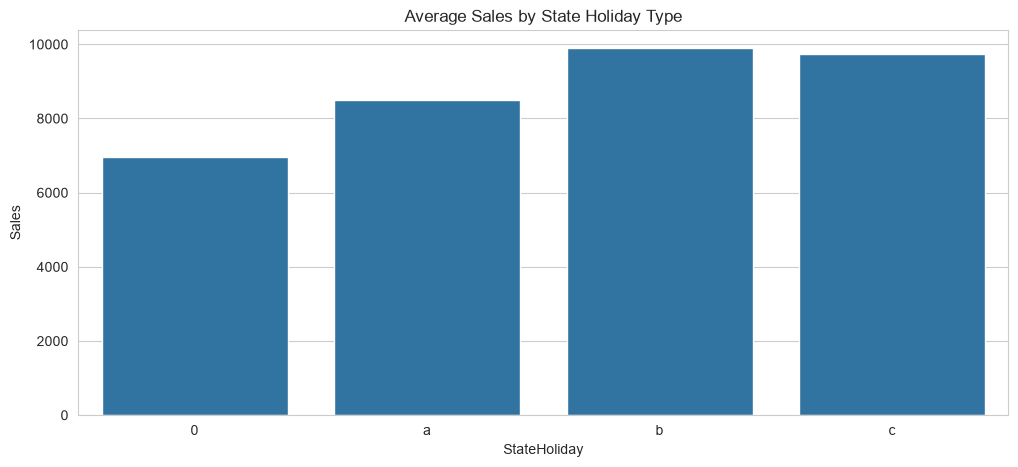

In [12]:
sns.barplot(data=df_open, x='StateHoliday', y='Sales', errorbar=None)
plt.title('Average Sales by State Holiday Type')
plt.show()

## 7. Store-Level Variation

Not every store behaves the same way — look at variation by store type and a few individual
store time series to build intuition for how heterogeneous this panel is.

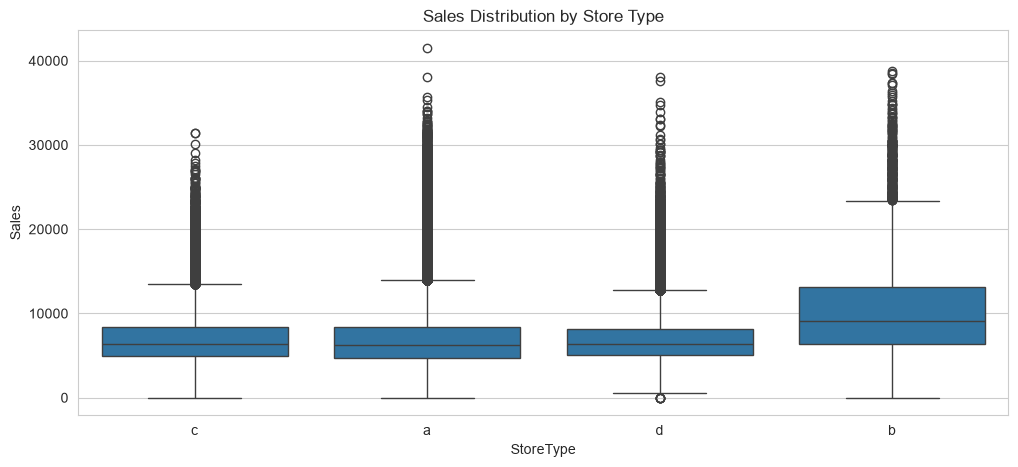

In [13]:
sns.boxplot(data=df_open, x='StoreType', y='Sales')
plt.title('Sales Distribution by Store Type')
plt.show()

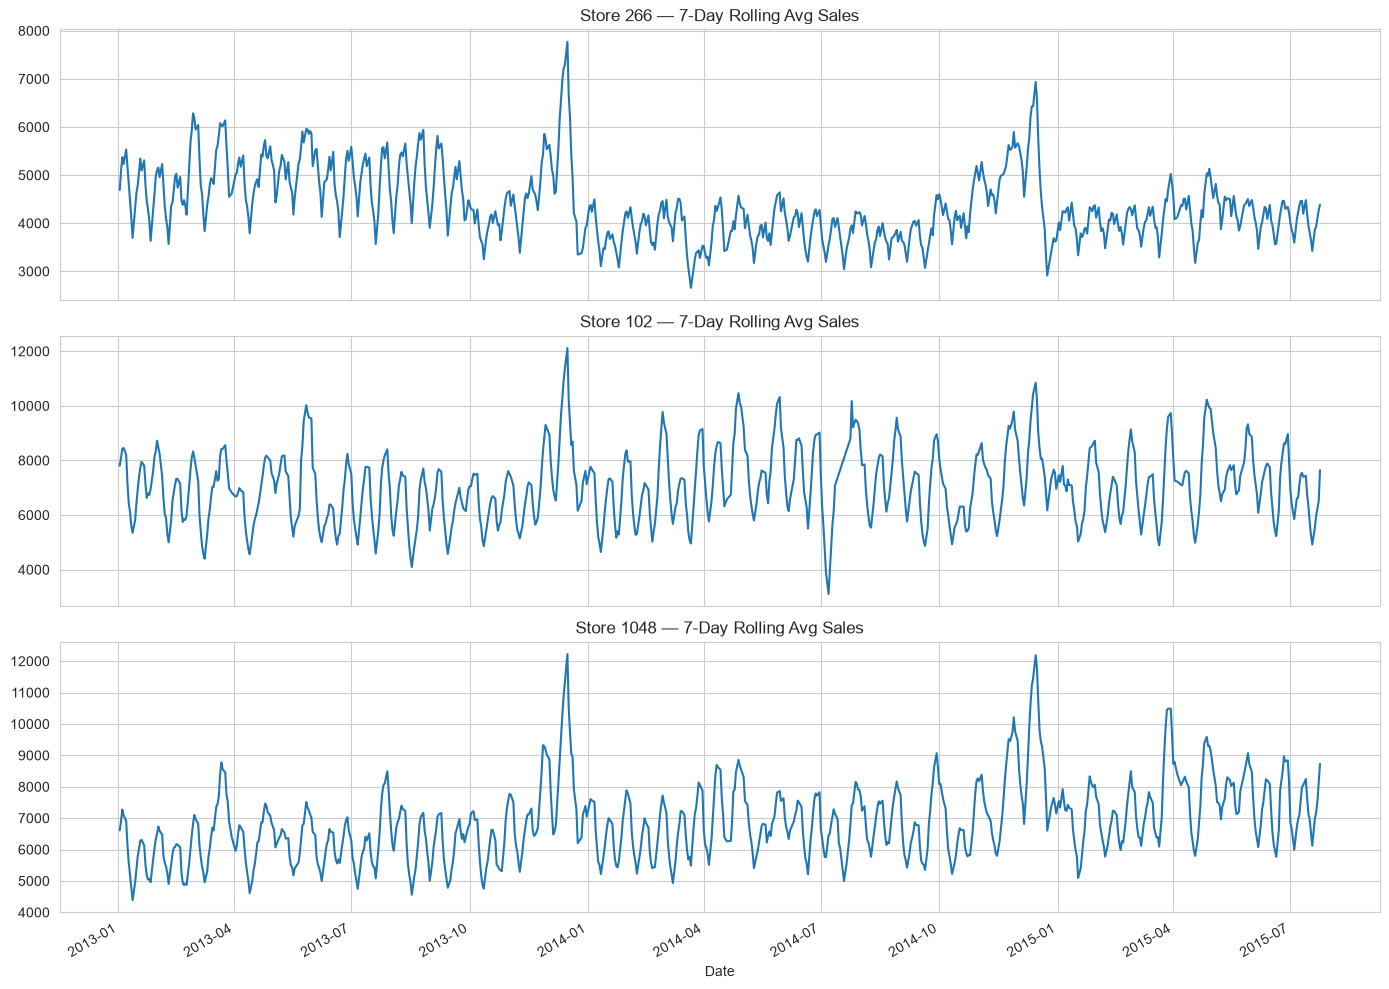

In [14]:
# Plot a few individual stores to see how different their patterns can be
sample_stores = df_open['Store'].drop_duplicates().sample(3, random_state=42)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, store_id in zip(axes, sample_stores):
    store_data = df_open[df_open['Store'] == store_id].set_index('Date')['Sales']
    store_data.rolling(7).mean().plot(ax=ax)
    ax.set_title(f'Store {store_id} — 7-Day Rolling Avg Sales')

plt.tight_layout()
plt.show()